### Importação dos dados



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento


In [2]:
faturamento_medio_lojas = {
    'Loja 1': loja['Preço'].mean(),
    'Loja 2': loja2['Preço'].mean(),
    'Loja 3': loja3['Preço'].mean(),
    'Loja 4': loja4['Preço'].mean(),
}

for nome_lojas, faturamento in faturamento_medio_lojas.items():
  print(f'{nome_lojas} teve faturamento de R$ {faturamento:.2f}')


Loja 1 teve faturamento de R$ 650.49
Loja 2 teve faturamento de R$ 630.97
Loja 3 teve faturamento de R$ 620.61
Loja 4 teve faturamento de R$ 587.15


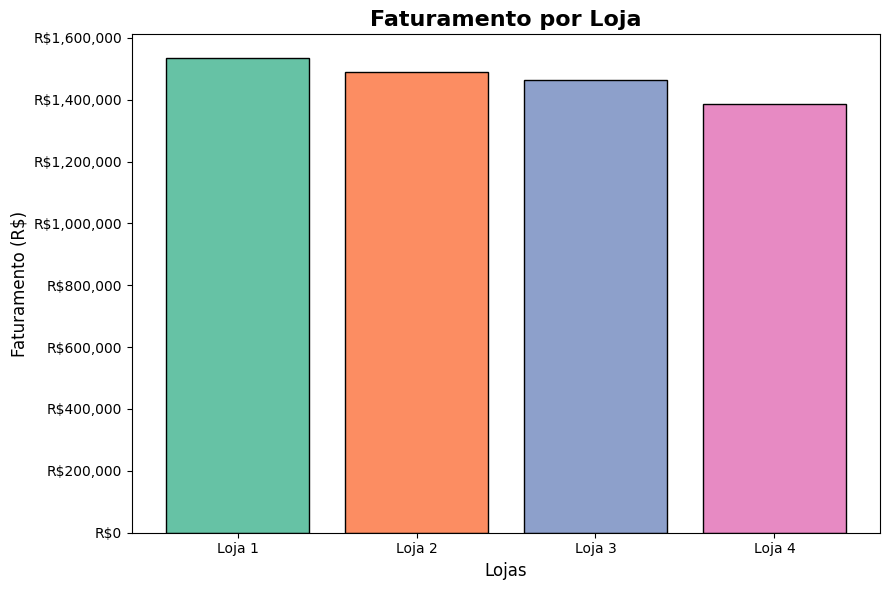

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Dicionário de faturamento
faturamento_lojas = {
    'Loja 1': loja['Preço'].sum(),
    'Loja 2': loja2['Preço'].sum(),
    'Loja 3': loja3['Preço'].sum(),
    'Loja 4': loja4['Preço'].sum(),
}

lojasN = list(faturamento_lojas.keys())
faturamentoL = list(faturamento_lojas.values())

fig, ax = plt.subplots(figsize=(9, 6))
cores = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
barras = ax.bar(lojasN, faturamentoL, color=cores, edgecolor='black', linewidth=1)
ax.set_title('Faturamento por Loja', fontsize=16, fontweight='bold')
ax.set_xlabel('Lojas', fontsize=12)
ax.set_ylabel('Faturamento (R$)', fontsize=12)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('R${x:,.0f}'))
plt.tight_layout()
plt.show()

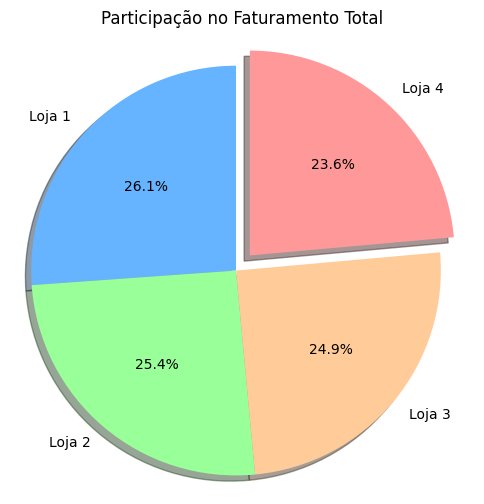

In [4]:
total = sum(faturamentoL)
porcentagens = [f / total for f in faturamentoL]

plt.figure(figsize=(6, 6))
plt.pie(porcentagens, labels=lojasN, autopct='%1.1f%%', startangle=90, shadow=True, explode=[0, 0, 0, 0.1], colors=['#66b3ff', '#99ff99', '#ffcc99', '#ff9999'])
plt.title('Participação no Faturamento Total')
plt.axis('equal')
plt.show()

# 2. Vendas por Categoria


In [5]:
vendas_categoria = {
    'Loja 1': loja['Categoria do Produto'].value_counts(),
    'Loja 2': loja2['Categoria do Produto'].value_counts(),
    'Loja 3': loja3['Categoria do Produto'].value_counts(),
    'Loja 4': loja4['Categoria do Produto'].value_counts(),
}

for nome_lojas, categoria in vendas_categoria.items():
  print(f'{nome_lojas}: {categoria}\n')




Loja 1: Categoria do Produto
moveis                   465
eletronicos              448
brinquedos               324
eletrodomesticos         312
esporte e lazer          284
instrumentos musicais    182
livros                   173
utilidades domesticas    171
Name: count, dtype: int64

Loja 2: Categoria do Produto
moveis                   442
eletronicos              422
brinquedos               313
eletrodomesticos         305
esporte e lazer          275
instrumentos musicais    224
livros                   197
utilidades domesticas    181
Name: count, dtype: int64

Loja 3: Categoria do Produto
moveis                   499
eletronicos              451
brinquedos               315
eletrodomesticos         278
esporte e lazer          277
livros                   185
instrumentos musicais    177
utilidades domesticas    177
Name: count, dtype: int64

Loja 4: Categoria do Produto
moveis                   480
eletronicos              451
brinquedos               338
esporte e lazer     

# 3. Média de Avaliação das Lojas

In [6]:
avaliacao_lojas = {
    'Loja 1': loja['Avaliação da compra'].mean(),
    'Loja 2': loja2['Avaliação da compra'].mean(),
    'Loja 3': loja3['Avaliação da compra'].mean(),
    'Loja 4': loja4['Avaliação da compra'].mean(),
}

for nome_lojas, avaliacao in avaliacao_lojas.items():
  print(f'{nome_lojas} teve avaliaçao média de {avaliacao:.1f}')


Loja 1 teve avaliaçao média de 4.0
Loja 2 teve avaliaçao média de 4.0
Loja 3 teve avaliaçao média de 4.0
Loja 4 teve avaliaçao média de 4.0


# 4. Produtos Mais e Menos Vendidos

In [7]:
total_vendas_geral = loja['Categoria do Produto'].value_counts() + loja2['Categoria do Produto'].value_counts() + loja3['Categoria do Produto'].value_counts() + loja4['Categoria do Produto'].value_counts()
mais_vendido_geral = total_vendas_geral.idxmax()
menos_vendido_geral = total_vendas_geral.idxmin()

contagem_loja = loja['Categoria do Produto'].value_counts()
mais_vendido_loja = contagem_loja.idxmax()
menos_vendido_loja = contagem_loja.idxmin()

contagem_loja2 = loja2['Categoria do Produto'].value_counts()
mais_vendido_loja2 = contagem_loja2.idxmax()
menos_vendido_loja2 = contagem_loja2.idxmin()

contagem_loja3 = loja3['Categoria do Produto'].value_counts()
mais_vendido_loja3 = contagem_loja3.idxmax()
menos_vendido_loja3 = contagem_loja3.idxmin()

contagem_loja4 = loja4['Categoria do Produto'].value_counts()
mais_vendido_loja4 = contagem_loja4.idxmax()
menos_vendido_loja4 = contagem_loja4.idxmin()

print('LOJA 01')
print(f'O produto mais vendido foi: {mais_vendido_loja} com {contagem_loja[mais_vendido_loja]} vendas')
print(f'O produto menos vendido foi: {menos_vendido_loja} com {contagem_loja[menos_vendido_loja]} vendas\n')

print('LOJA 02')
print(f'O produto mais vendido foi: {mais_vendido_loja2} com {contagem_loja2[mais_vendido_loja2]} vendas')
print(f'O produto menos vendido foi: {menos_vendido_loja2} com {contagem_loja2[menos_vendido_loja2]} vendas\n')

print('LOJA 03')
print(f'O produto mais vendido foi: {mais_vendido_loja3} com {contagem_loja3[mais_vendido_loja3]} vendas')
print(f'O produto menos vendido foi: {menos_vendido_loja3} com {contagem_loja3[menos_vendido_loja3]} vendas\n')

print('LOJA 04')
print(f'O produto mais vendido foi: {mais_vendido_loja4} com {contagem_loja4[mais_vendido_loja4]} vendas')
print(f'O produto menos vendido foi: {menos_vendido_loja}4 com {contagem_loja4[menos_vendido_loja4]} vendas\n')

print('TOTAL DE VENDAS NAS 4 LOJAS')
print(total_vendas_geral)
print('\n')
print(f'O produto mais vendido foi: {mais_vendido_geral} com {total_vendas_geral[mais_vendido_geral]} vendas')
print(f'O produto menos vendido foi: {menos_vendido_geral} com {total_vendas_geral[menos_vendido_geral]} vendas')

print('\n')


LOJA 01
O produto mais vendido foi: moveis com 465 vendas
O produto menos vendido foi: utilidades domesticas com 171 vendas

LOJA 02
O produto mais vendido foi: moveis com 442 vendas
O produto menos vendido foi: utilidades domesticas com 181 vendas

LOJA 03
O produto mais vendido foi: moveis com 499 vendas
O produto menos vendido foi: instrumentos musicais com 177 vendas

LOJA 04
O produto mais vendido foi: moveis com 480 vendas
O produto menos vendido foi: utilidades domesticas4 com 170 vendas

TOTAL DE VENDAS NAS 4 LOJAS
Categoria do Produto
brinquedos               1290
eletrodomesticos         1149
eletronicos              1772
esporte e lazer          1113
instrumentos musicais     753
livros                    742
moveis                   1886
utilidades domesticas     730
Name: count, dtype: int64


O produto mais vendido foi: moveis com 1886 vendas
O produto menos vendido foi: utilidades domesticas com 730 vendas




# 5. Frete Médio por Loja


In [8]:
frete_medio = {
    'LOJA 1': loja['Frete'].mean(),
    'LOJA 2': loja2['Frete'].mean(),
    'LOJA 3': loja3['Frete'].mean(),
    'LOJA 4': loja4['Frete'].mean(),
}

todas_as_lojas = pd.concat([loja, loja2, loja3, loja4])
frete_medio_total = todas_as_lojas['Frete'].mean()

for nome_lojas, frete in frete_medio.items():
  print(f'O valor do frete medio da {nome_lojas} foi de R$ {frete:.2f}\n')
print(f'O valor do frete medio TOTAL é de R$ {frete_medio_total:.2f}')



O valor do frete medio da LOJA 1 foi de R$ 34.69

O valor do frete medio da LOJA 2 foi de R$ 33.62

O valor do frete medio da LOJA 3 foi de R$ 33.07

O valor do frete medio da LOJA 4 foi de R$ 31.28

O valor do frete medio TOTAL é de R$ 33.17


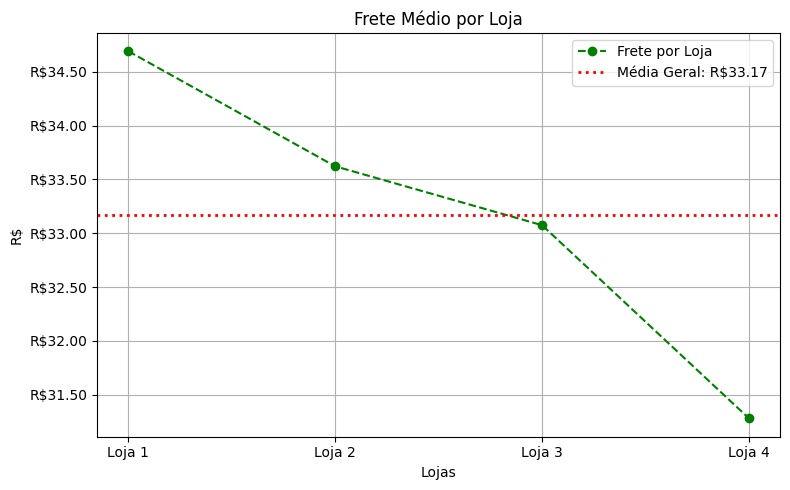

In [9]:
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt

frete_medio = [
    loja['Frete'].mean(),
    loja2['Frete'].mean(),
    loja3['Frete'].mean(),
    loja4['Frete'].mean()
]

frete_medio_total = sum(frete_medio) / len(frete_medio)

plt.figure(figsize=(8, 5))
plt.plot(lojasN, frete_medio, marker='o', linestyle='--', color='green', label='Frete por Loja')
plt.axhline(frete_medio_total, color='red', linestyle=':', linewidth=2, label=f'Média Geral: R${frete_medio_total:.2f}')

plt.title('Frete Médio por Loja')
plt.ylabel('R$')
plt.xlabel('Lojas')
plt.grid(True)
plt.legend()

# Aplica a formatação do eixo Y como moeda (R$)
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('R${x:,.2f}'))

plt.tight_layout()
plt.show()

# Relatório

# **Relatório de Análise de Vendas - Lojas do Sr. João**

Neste relatório, apresentamos uma análise dos dados de vendas das quatro lojas do Sr. João, com base no conjunto de dados fornecido. O objetivo principal foi identificar o desempenho individual de cada loja em termos de faturamento total e frete médio, utilizando gráficos e métricas estatísticas básicas.

Durante a análise, observamos que a avaliação das lojas não foi um fator relevante para a tomada de decisão, pois todas apresentaram valores iguais. Da mesma forma, o frete médio também não se mostrou decisivo, já que os valores ficaram muito próximos entre as lojas.

O fator determinante foi o faturamento total de cada unidade, calculado pela somatória dos valores de venda por loja. A partir disso, geramos um gráfico de barras que evidenciou de forma clara as diferenças no desempenho financeiro entre elas.

# Principais Conclusões:
A Loja 4 apresentou o menor faturamento entre as quatro analisadas.

Os dados foram apresentados em um gráfico de barras personalizado, facilitando a comparação entre as lojas.

Para ampliar a visualização, também geramos um gráfico de pizza, permitindo observar a participação percentual de cada loja no faturamento total.

Além disso, criamos um gráfico de linha para ilustrar o frete médio por loja, com uma linha horizontal indicando a média geral, possibilitando a identificação de variações positivas ou negativas em relação a essa média.

